# **Visualisation one frame radius graph** 

## **Imports:**

In [3]:
# import os
# from typing import Optional
# import lightning

# # Import required libraries
# import h5py
# import matplotlib.pyplot as plt
# import numpy as np
# import torch
# from torch_geometric.nn import radius_graph

# file_path = "/home/tkalinov/snap/snapd-desktop-integration/253/Documents/sph_les_directory/sph_les/data/2D_TGV_2500_10kevery100/valid.h5"

## Basically just plotting

['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010', '00011', '00012', '00013', '00014', '00015', '00016', '00017', '00018', '00019', '00020', '00021', '00022', '00023', '00024', '00025', '00026', '00027', '00028', '00029', '00030', '00031', '00032', '00033', '00034', '00035', '00036', '00037', '00038', '00039', '00040', '00041', '00042', '00043', '00044', '00045', '00046', '00047', '00048', '00049']


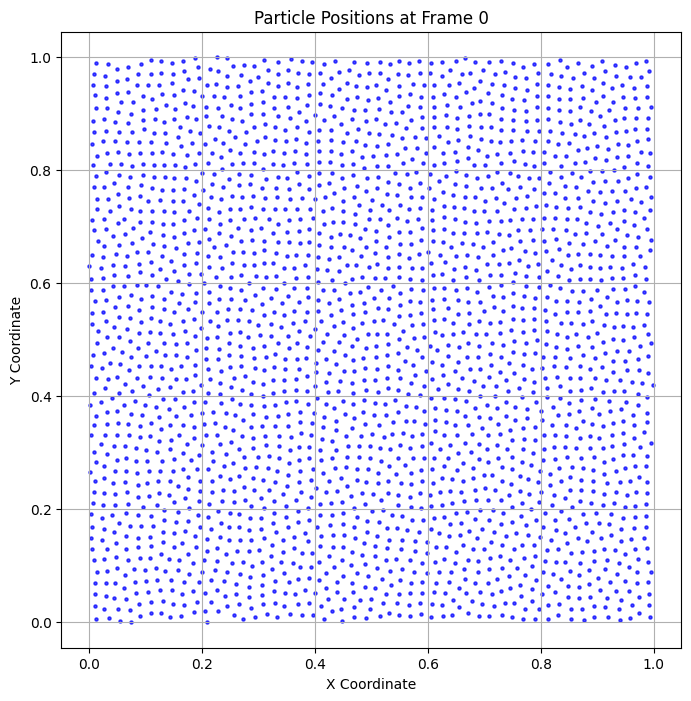

In [8]:
# with h5py.File(file_path, 'r') as f:
#     # Inspect the file structure (uncomment to print keys if needed)
#     print(list(f.keys()))

#     # Assume 'positions' dataset contains the trajectory data
#     # Replace 'positions' with the correct dataset name if different
#     trajectory_data = f['00000/position'][:]  # Shape: (126, 2500, 2) - (time, particles, spatial_dims)
#     frame_index = 0  # Select the first frame
#     frame_data = trajectory_data[frame_index]  # Shape: (2500, 2)

# # Extract X and Y coordinates
# x_coords = frame_data[:, 0]
# y_coords = frame_data[:, 1]

# # Create a scatter plot
# plt.figure(figsize=(8, 8))
# plt.scatter(x_coords, y_coords, s=5, c='blue', alpha=0.7)
# plt.title(f'Particle Positions at Frame {frame_index}')
# plt.xlabel('X Coordinate')
# plt.ylabel('Y Coordinate')
# plt.axis('equal')
# plt.grid(True)
# plt.show()


## Copy the frame 8 times around itself

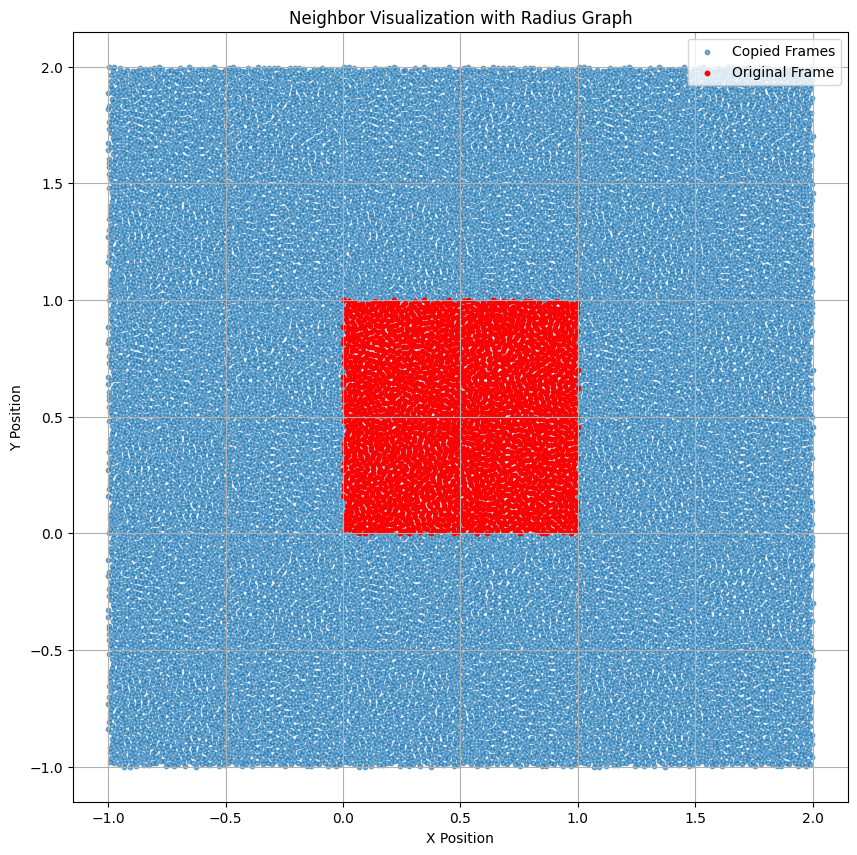

In [6]:
with h5py.File(file_path, "r") as f:
    position = f["00000/position"][:]  # Load one frame
    frame = position[-1]  # Use the last time step of the sequence (shape: [2500, 2])

# Convert to PyTorch tensor
frame_tensor = torch.tensor(frame, dtype=torch.float)

# Create 8 surrounding copies of the frame for periodic boundary visualization
offsets = torch.tensor([
    [-1, -1], [-1, 0], [-1, 1],
    [0, -1], [0, 1],
    [1, -1], [1, 0], [1, 1]
], dtype=torch.float)

copied_frames = torch.cat([frame_tensor + offset for offset in offsets])
all_frames = torch.cat([frame_tensor, copied_frames])

# Apply radius graph with a specific radius
radius = 0.0029
edge_index = radius_graph(all_frames, r=radius)

# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(all_frames[:, 0], all_frames[:, 1], s=10, alpha=0.6, label="Copied Frames")
plt.scatter(frame_tensor[:, 0], frame_tensor[:, 1], color='red', s=10, label="Original Frame")

# Add lines for neighbors
for edge in edge_index.t():
    start, end = edge
    plt.plot(
        [all_frames[start, 0], all_frames[end, 0]],
        [all_frames[start, 1], all_frames[end, 1]],
        color="blue",
        alpha=0.5,
        linewidth=0.5
    )

plt.title("Neighbor Visualization with Radius Graph")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()

# Testing PyG radius_graph w/o PBC

Traceback (most recent call last):
  File "/home/tkalinov/snap/snapd-desktop-integration/current/Documents/sph_les_directory/sph_les/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_vars.py", line 622, in change_attr_expression
    value = eval(expression, frame.f_globals, frame.f_locals)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 1, in <module>
NameError: name 'tensor' is not defined


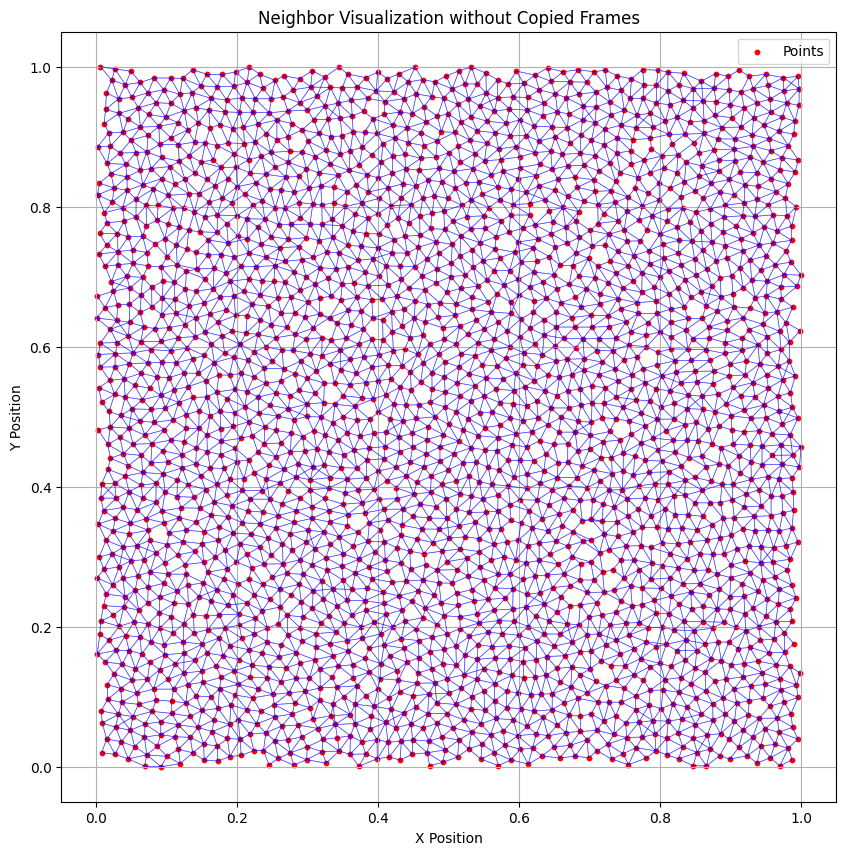

In [10]:
import h5py
import torch
from torch_geometric.nn import radius_graph
import matplotlib.pyplot as plt

# Load the dataset
with h5py.File(file_path, "r") as f:
    position = f["00000/position"][:]  # Load one trajectory
    frame = position[-1]  # Use the last time step of the sequence (shape: [2500, 2])

# Convert to PyTorch tensor
frame_tensor = torch.tensor(frame, dtype=torch.float)

# Apply radius graph with a specific radius
radius = 0.029
edge_index = radius_graph(frame_tensor, r=radius)

# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(frame_tensor[:, 0], frame_tensor[:, 1], color='red', s=10, label="Points")

# Add lines for neighbors
for edge in edge_index.t():
    start, end = edge
    plt.plot(
        [frame_tensor[start, 0], frame_tensor[end, 0]],
        [frame_tensor[start, 1], frame_tensor[end, 1]],
        color="blue",
        alpha=0.5,
        linewidth=0.5
    )

plt.title("Neighbor Visualization without Copied Frames")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()


## Trying to make an animation

[[[0.01252489 0.00544468]
  [0.036316   0.00796867]
  [0.05519401 0.00249588]
  ...
  [0.9514955  0.9823426 ]
  [0.96913725 0.98906654]
  [0.98629284 0.9930397 ]]

 [[0.0111226  0.00836744]
  [0.03376324 0.0167866 ]
  [0.05339507 0.01576081]
  ...
  [0.9572313  0.97135913]
  [0.9730346  0.9821027 ]
  [0.98871475 0.98995197]]

 [[0.00849652 0.01068212]
  [0.02873896 0.024216  ]
  [0.04826753 0.0276041 ]
  ...
  [0.96472263 0.9623415 ]
  [0.97766644 0.9763045 ]
  [0.9912335  0.98756313]]

 ...

 [[0.02607212 0.99655837]
  [0.04898676 0.99314576]
  [0.06212158 0.977154  ]
  ...
  [0.9495118  0.989049  ]
  [0.9746076  0.9841345 ]
  [0.99528486 0.9858094 ]]

 [[0.02608588 0.99659026]
  [0.04899825 0.9931844 ]
  [0.0621325  0.9771928 ]
  ...
  [0.9495063  0.989007  ]
  [0.97461206 0.9841153 ]
  [0.9952954  0.98580587]]

 [[0.02609871 0.99662024]
  [0.04900854 0.99322015]
  [0.06214145 0.97722834]
  ...
  [0.9495008  0.9889673 ]
  [0.97461593 0.9840971 ]
  [0.99530506 0.9858022 ]]]
torch.Size

KeyboardInterrupt: 

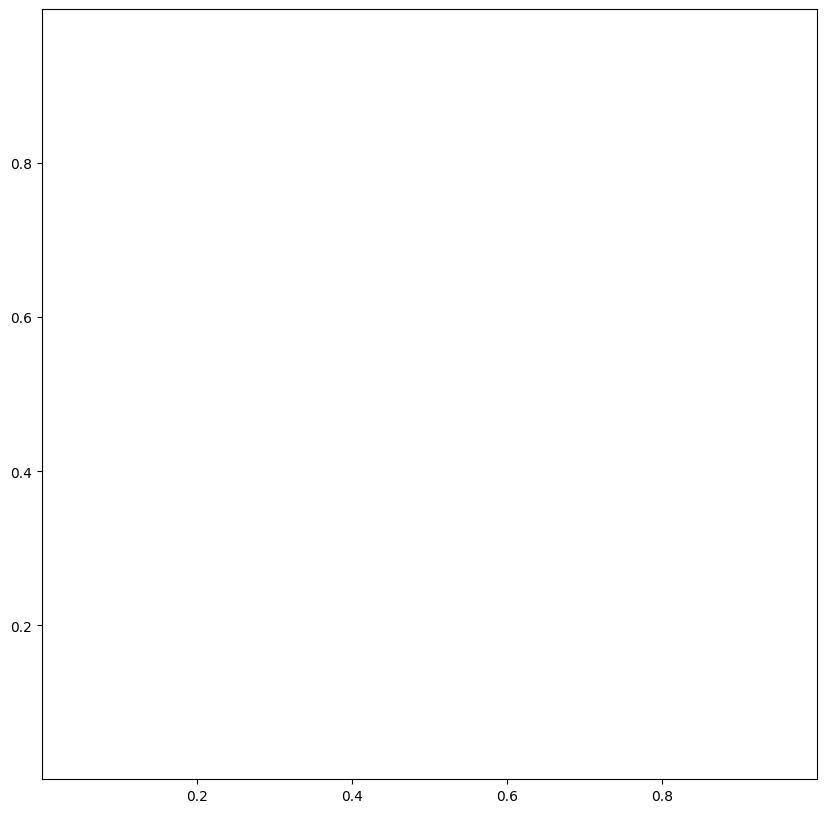

In [5]:
from matplotlib.animation import FuncAnimation

with h5py.File(file_path, "r") as f:
    position = f["00000/position"][:]  # Load one trajectory (shape: [time_steps, 2500, 2])

# Convert to PyTorch tensor
position_tensor = torch.tensor(position, dtype=torch.float)
radius = 0.029  # Radius for neighbor detection

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter([], [], color="red", s=10, label="Points")
lines = []

# Function to update the plot for each frame
def update(frame_idx):
    global lines
    # Clear previous lines
    for line in lines:
        line.remove()
    lines = []

    # Get current frame
    current_frame = position_tensor[frame_idx]

    # Apply radius graph
    edge_index = radius_graph(current_frame, r=radius)

    # Update scatter plot
    scatter.set_offsets(current_frame.numpy())

    # Add lines for neighbors
    for edge in edge_index.t():
        start, end = edge
        line, = ax.plot(
            [current_frame[start, 0], current_frame[end, 0]],
            [current_frame[start, 1], current_frame[end, 1]],
            color="blue",
            alpha=0.5,
            linewidth=0.5
        )
        lines.append(line)

    # Update title with the current time step
    ax.set_title(f"Neighbor Visualization - Time Step {frame_idx+1}")

# Set axis limits and labels
ax.set_xlim(position_tensor[:, :, 0].min().item(), position_tensor[:, :, 0].max().item())
ax.set_ylim(position_tensor[:, :, 1].min().item(), position_tensor[:, :, 1].max().item())
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.legend()
ax.grid(True)

# Create the animation
ani = FuncAnimation(fig, update, frames=range(position_tensor.shape[0]), interval=500, repeat=True)

# Show the animation
plt.show()


# Testing PyG radius_graph with PBC

Note: particles outside of the middle frame are simply representations of particles in the frame, obiding to the conditions of periodcity

/tmp/ipykernel_3347833/3650095476.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  frame_tensor = torch.tensor(frame, dtype=torch.float)


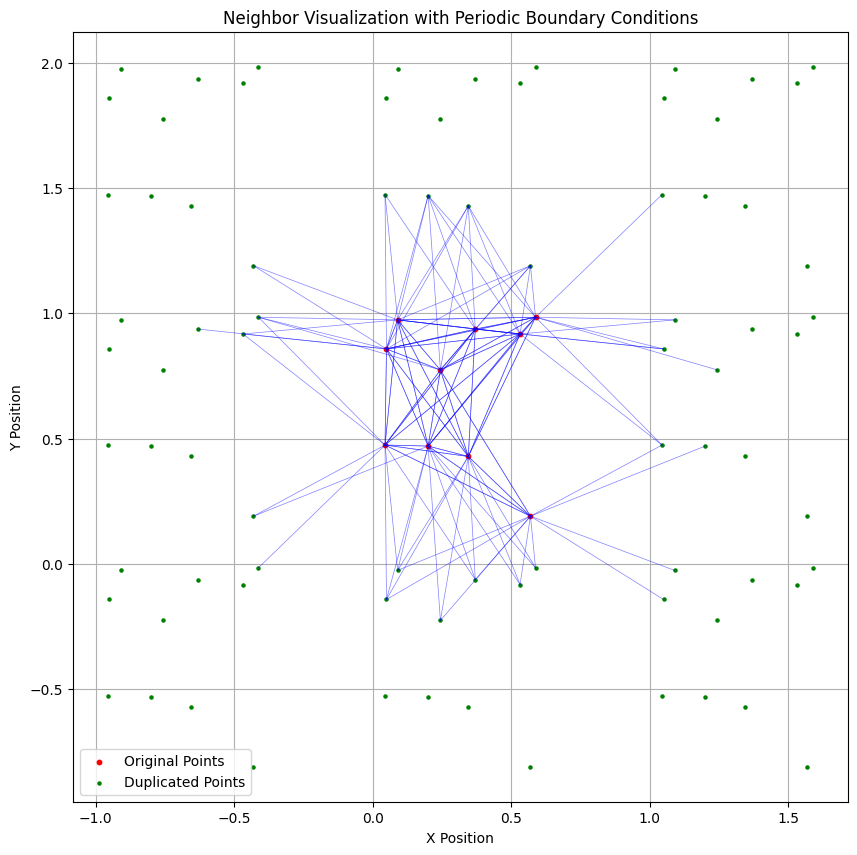

In [5]:
import h5py
import torch
from torch_geometric.nn import radius_graph
import matplotlib.pyplot as plt

# Load the dataset
with h5py.File(file_path, "r") as f:
    position = f["00000/position"][:]  # Load one trajectory
    frame = position[-1]  # Use the last time step of the sequence (shape: [2500, 2])

# Define domain size and periodic boundary shifts
frame = torch.rand(10, 2)
# Convert to PyTorch tensor
frame_tensor = torch.tensor(frame, dtype=torch.float)


# Define domain size and periodic boundary shifts
domain_size = torch.tensor([1.0, 1.0])  # Assuming a unit square domain
shifts = torch.tensor([
    [dx, dy] for dx in [-1, 0, 1] for dy in [-1, 0, 1] if not (dx == 0 and dy == 0)
]).float() * domain_size  # Exclude the center (original frame)

# Duplicate the frame with periodic shifts
duplicated_frames = torch.cat([
    frame_tensor + shift for shift in shifts
], dim=0)  # Shape: [2500 * 8, 2]

# Combine original frame and duplicated frames for neighbor search
combined_positions = torch.cat([frame_tensor, duplicated_frames], dim=0)  # Shape: [2500 * 9, 2]

# Apply radius graph only for original particles
radius = 0.7
mapped_positions = (combined_positions % domain_size).clone()
edge_index = radius_graph(combined_positions, r=radius)

# Filter edges to ensure both source and target are within the original frame
original_frame_size = frame_tensor.size(0)
is_from_original = edge_index[0] < original_frame_size
filtered_edge_index = edge_index[:, is_from_original]

# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(frame_tensor[:, 0], frame_tensor[:, 1], color='red', s=10, label="Original Points")
plt.scatter(duplicated_frames[:, 0], duplicated_frames[:, 1], color='green', s=5, label="Duplicated Points")

# Add lines for neighbors
for edge in filtered_edge_index.t():
    start, end = edge
    plt.plot(
        [combined_positions[start, 0], combined_positions[end, 0]],
        [combined_positions[start, 1], combined_positions[end, 1]],
        color="blue",
        alpha=0.5,
        linewidth=0.5
    )

plt.title("Neighbor Visualization with Periodic Boundary Conditions")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()


**Test cell list algo**

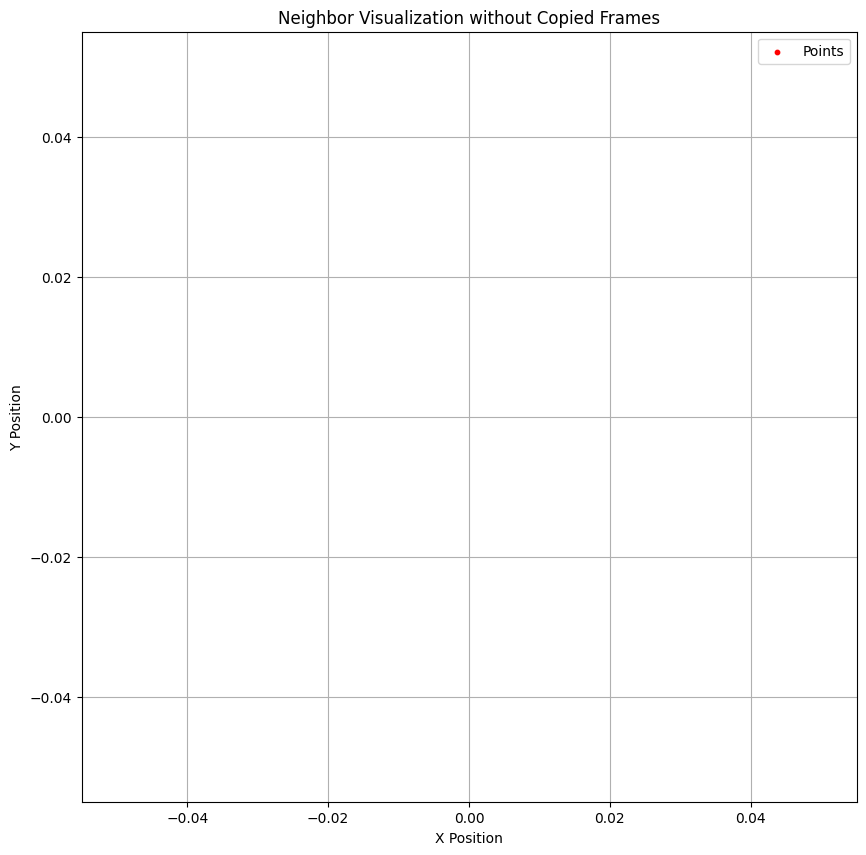

In [4]:
import torch
import h5py
import torch
from torch_geometric.nn import radius_graph
import matplotlib.pyplot as plt

def cell_list_neighbor_search(positions, box_size, radius):
    """
    Custom neighbor search using cell-list algorithm with periodic boundary conditions.
    Args:
        positions: Tensor of shape (N, D) for N particles in D dimensions.
        box_size: Tensor of shape (D,) for box dimensions.
        radius: Cutoff radius for neighbor search.
    Returns:
        senders: Indices of sender particles.
        receivers: Indices of receiver particles.
    """
    N, D = positions.size()
    cell_size = radius + 1e-6  # Ensure cells are slightly larger than radius
    num_cells = (box_size / cell_size).long()

    # Compute cell indices for each particle
    cell_indices = (positions / cell_size).long() % num_cells #Indices of the cells that each particle belongs to in each dimension
    # Flatten cell indices into a 1D cell ID
    cell_ids = torch.zeros(N, dtype=torch.long, device=positions.device) #Initialize the cell_ids tensor for each particles
    for d in range(D):
        cell_ids += cell_indices[:, d] * torch.prod(num_cells[d+1:]) # This line makes sure that the 

    # Group particles by cell
    cell_dict = {}
    for i, cell_id in enumerate(cell_ids):
        if cell_id.item() not in cell_dict:
            cell_dict[cell_id.item()] = []
        cell_dict[cell_id.item()].append(i)

    # Add ghost cells
    ghost_cells = {}
    for cell_id in cell_dict.keys():
        neighbors = get_neighbor_cells(cell_id, num_cells)
        ghost_cells[cell_id] = neighbors

    # Compute neighbors
    senders, receivers = [], []
    for cell_id, particles in cell_dict.items():
        # Include particles from neighboring cells
        all_neighbors = []
        for neighbor_cell in ghost_cells[cell_id]:
            if neighbor_cell in cell_dict:
                all_neighbors.extend(cell_dict[neighbor_cell])

        # Compute pairwise distances within and between cells
        for i in particles:
            for j in all_neighbors:
                if i != j:
                    displacement = positions[i] - positions[j]
                    displacement -= torch.round(displacement / box_size) * box_size  # Apply PBC
                    distance = displacement.norm()
                    if distance <= radius:
                        senders.append(i)
                        receivers.append(j)

    return torch.tensor(senders), torch.tensor(receivers)

def get_neighbor_cells(cell_id, num_cells):
    """
    Get neighboring cell IDs, including periodic boundaries.
    Args:
        cell_id: Current cell ID.
        num_cells: Number of cells in each dimension.
    Returns:
        neighbors: List of neighboring cell IDs.
    """
    # Convert 1D cell ID back to multi-dimensional indices
    indices = []
    for i in range(len(num_cells)):
        indices.append(cell_id % num_cells[i])
        cell_id //= num_cells[i]

    neighbors = []
    for offset in torch.cartesian_prod(*[torch.tensor([-1, 0, 1]) for _ in range(len(num_cells))]):
        neighbor = (torch.tensor(indices) + offset) % num_cells
        neighbors.append(neighbor)

    # Convert neighbor indices back to 1D cell IDs
    neighbor_ids = []
    for neighbor in neighbors:
        neighbor_id = 0
        for d in range(len(num_cells)):
            neighbor_id += neighbor[d] * torch.prod(num_cells[d+1:])
        neighbor_ids.append(neighbor_id)

    return neighbor_ids

# Load the dataset
with h5py.File(file_path, "r") as f:
    position = f["00000/position"][:]  # Load one trajectory
    frame = position[-1]  # Use the last time step of the sequence (shape: [2500, 2])

# Convert to PyTorch tensor
frame_tensor = torch.tensor(frame, dtype=torch.float)

box_size = torch.tensor([1.0, 1.0])  # Assuming a unit square domain
# Apply radius graph with a specific radius
radius = 0.0029
senders, receivers = cell_list_neighbor_search(frame_tensor, box_size, radius)

# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(senders, receivers, color='red', s=10, label="Points")

# Add lines for neighbors
for edge in zip(senders, receivers):
    start, end = edge
    plt.plot(
        [frame_tensor[start, 0], frame_tensor[end, 0]],
        [frame_tensor[start, 1], frame_tensor[end, 1]],
        color="blue",
        alpha=0.5,
        linewidth=0.5
    )

plt.title("Neighbor Visualization without Copied Frames")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()


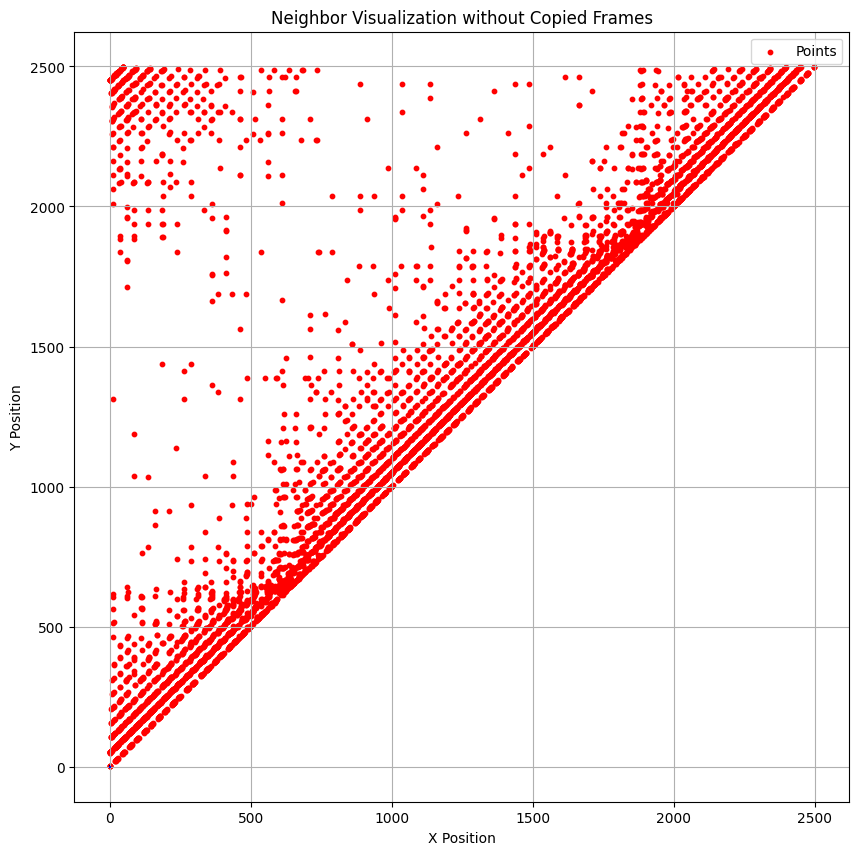

In [13]:
import torch

def cell_list_neighbor_search(
    positions: torch.Tensor,
    box: torch.Tensor = torch.tensor([1., 1.]),
    cutoff: float = 0.1
):
    """
    Cell-list based neighbor search in 2D with periodic boundary conditions (PBC).

    Args:
        positions (torch.Tensor): Shape (N, 2). Particle positions.
        box (torch.Tensor): Shape (2,). Box dimensions, default [1,1].
        cutoff (float): Cutoff distance for neighbor search.

    Returns:
        (torch.Tensor, torch.Tensor): Two 1D tensors (senders, receivers)
        listing the neighbor pairs (i, j), with i < j.
    """
    # Wrap positions to ensure all are inside the [0, box[i]) domain
    positions = positions % box

    # Number of cells along each dimension
    n_cells = (box / cutoff).to(torch.int)
    # Cell size along each dimension
    cell_size = box / n_cells

    # Assign each particle to a cell index in x and y direction
    cell_indices = torch.floor(positions / cell_size).to(torch.int)

    # Create a list of empty lists to store the particles that fall in each cell
    # We'll flatten the cell grid into a 1D list for easy indexing
    max_cell_x, max_cell_y = n_cells[0].item(), n_cells[1].item()
    cell_list = [[] for _ in range(max_cell_x * max_cell_y)]

    def flatten_cell_ix(ix_x, ix_y):
        """Convert 2D cell coordinates to single index."""
        return ix_x * max_cell_y + ix_y

    # Populate the cell_list with particle indices
    for i in range(len(positions)):
        cix_x = cell_indices[i, 0]
        cix_y = cell_indices[i, 1]
        cix_flat = flatten_cell_ix(cix_x, cix_y)
        cell_list[cix_flat].append(i)

    # Prepare to collect neighbor pairs
    senders = []
    receivers = []

    # Relative shifts to neighbor cells in 2D (including the cell itself)
    neighbor_shifts = [-1, 0, 1]

    # Check each cell and its neighbors
    for cix_x in range(max_cell_x):
        for cix_y in range(max_cell_y):
            # Indices of particles in the current cell
            cix_flat = flatten_cell_ix(cix_x, cix_y)
            current_particles = cell_list[cix_flat]

            # Loop over all neighboring cells (including the current one)
            for dx in neighbor_shifts:
                for dy in neighbor_shifts:
                    # Wrap neighbor cell indices modulo the number of cells for PBC
                    nx = (cix_x + dx) % max_cell_x
                    ny = (cix_y + dy) % max_cell_y
                    neighbor_particles = cell_list[flatten_cell_ix(nx, ny)]

                    # Build neighbor pairs
                    for i_idx in current_particles:
                        for j_idx in neighbor_particles:
                            # Avoid double-counting: only count i < j
                            if i_idx < j_idx:
                                # Compute distance with minimum-image convention
                                dr = positions[j_idx] - positions[i_idx]
                                # Apply nearest image under PBC
                                dr -= box * torch.round(dr / box)
                                dist2 = torch.sum(dr**2)
                                if dist2 < cutoff**2:
                                    senders.append(i_idx)
                                    receivers.append(j_idx)

    # Convert lists to PyTorch tensors
    senders = torch.tensor(senders, dtype=torch.long)
    receivers = torch.tensor(receivers, dtype=torch.long)

    return senders, receivers

with h5py.File(file_path, "r") as f:
    position = f["00000/position"][:]  # Load one trajectory
    frame = position[-1]  # Use the last time step of the sequence (shape: [2500, 2])

# Convert to PyTorch tensor
frame_tensor = torch.tensor(frame, dtype=torch.float)

box_size = torch.tensor([1.0, 1.0])  # Assuming a unit square domain
# Apply radius graph with a specific radius
radius = 0.029
senders, receivers = cell_list_neighbor_search(frame_tensor, box_size, radius)

# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(senders, receivers, color='red', s=10, label="Points")

# Add lines for neighbors
for edge in zip(senders, receivers):
    start, end = edge
    plt.plot(
        [frame_tensor[start, 0], frame_tensor[end, 0]],
        [frame_tensor[start, 1], frame_tensor[end, 1]],
        color="blue",
        alpha=0.5,
        linewidth=0.5
    )

plt.title("Neighbor Visualization without Copied Frames")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()



/home/tkalinov/snap/snapd-desktop-integration/current/Documents/sph_les_directory/sph_les/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


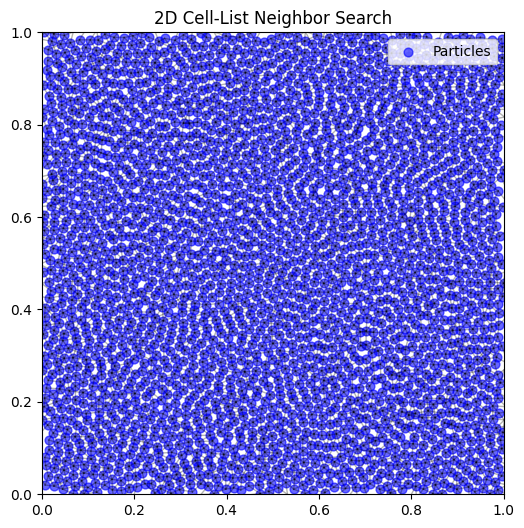

In [17]:
import torch
import matplotlib.pyplot as plt

def cell_list_neighbor_search(
    positions: torch.Tensor,
    box: torch.Tensor = torch.tensor([1., 1.]),
    cutoff: float = 0.1
):
    """
    Cell-list based neighbor search in 2D with periodic boundary conditions (PBC).

    Args:
        positions (torch.Tensor): Shape (N, 2). Particle positions.
        box (torch.Tensor): Shape (2,). Box dimensions, default [1,1].
        cutoff (float): Cutoff distance for neighbor search.

    Returns:
        (senders, receivers): Two 1D tensors listing neighbor pairs (i, j) with i < j.
    """
    # Wrap positions to ensure they are inside [0, box[0]) × [0, box[1])
    positions = positions % box

    # Number of cells along each dimension
    n_cells = (box / cutoff).to(torch.int)
    # Ensure at least 1 cell in each dimension
    n_cells = torch.clamp(n_cells, min=1)

    # Cell size along each dimension
    cell_size = box / n_cells

    # Assign each particle to a cell index in x and y
    cell_indices = torch.floor(positions / cell_size).to(torch.int)

    # Create a list of empty lists to store the particles that fall in each cell
    max_cell_x, max_cell_y = n_cells[0].item(), n_cells[1].item()
    cell_list = [[] for _ in range(max_cell_x * max_cell_y)]

    def flatten_cell_ix(ix_x, ix_y):
        """Convert 2D cell coordinates to single index."""
        return ix_x * max_cell_y + ix_y

    # Populate the cell_list with particle indices
    for i, pos in enumerate(positions):
        cix_x = cell_indices[i, 0]
        cix_y = cell_indices[i, 1]
        cix_flat = flatten_cell_ix(cix_x, cix_y)
        cell_list[cix_flat].append(i)

    # Prepare to collect neighbor pairs
    senders = []
    receivers = []

    # Relative shifts to neighbor cells in 2D (including the cell itself)
    neighbor_shifts = [-1, 0, 1]

    # Check each cell and its neighbors
    for cix_x in range(max_cell_x):
        for cix_y in range(max_cell_y):
            # Indices of particles in the current cell
            cix_flat = flatten_cell_ix(cix_x, cix_y)
            current_particles = cell_list[cix_flat]

            # Loop over all neighboring cells (including the current one)
            for dx in neighbor_shifts:
                for dy in neighbor_shifts:
                    # Wrap neighbor cell indices modulo the number of cells for PBC
                    nx = (cix_x + dx) % max_cell_x
                    ny = (cix_y + dy) % max_cell_y
                    neighbor_particles = cell_list[flatten_cell_ix(nx, ny)]

                    # Build neighbor pairs
                    for i_idx in current_particles:
                        for j_idx in neighbor_particles:
                            # Avoid double-counting (only consider i < j)
                            if i_idx < j_idx:
                                # Compute distance with minimum-image convention
                                dr = positions[j_idx] - positions[i_idx]
                                # Apply nearest image under PBC
                                dr -= box * torch.round(dr / box)
                                dist2 = torch.sum(dr**2)
                                if dist2 < cutoff**2:
                                    senders.append(i_idx)
                                    receivers.append(j_idx)

    # Convert lists to PyTorch tensors
    senders = torch.tensor(senders, dtype=torch.long)
    receivers = torch.tensor(receivers, dtype=torch.long)

    return senders, receivers


def visualize_neighbors(
    positions: torch.Tensor,
    senders: torch.Tensor,
    receivers: torch.Tensor,
    box: torch.Tensor = torch.tensor([1., 1.]),
    title: str = "Neighbor Visualization"
):
    """
    Visualize particle positions and draw lines between neighbor pairs.
    Uses periodic boundary conditions for plotting edges (optional).

    Args:
        positions (torch.Tensor): (N, 2) positions of particles.
        senders (torch.Tensor): 1D, indices of "sender" particles in neighbor pairs.
        receivers (torch.Tensor): 1D, indices of "receiver" particles in neighbor pairs.
        box (torch.Tensor): (2,) box dimensions, default [1,1].
        title (str): title of the plot
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # Wrap positions inside the box for better visualization
    positions = positions % box

    # Plot particle positions
    ax.scatter(positions[:, 0], positions[:, 1], s=40, c='blue', alpha=0.6, label='Particles')

    # Draw lines between neighbors
    for s, r in zip(senders, receivers):
        # Get the positions of the two neighboring particles
        x_s, y_s = positions[s]
        x_r, y_r = positions[r]

        # Compute the minimum-image displacement for plotting
        dr = torch.tensor([x_r - x_s, y_r - y_s])
        dr -= box * torch.round(dr / box)
        x_r_plot, y_r_plot = x_s + dr[0], y_s + dr[1]

        # Draw the line
        ax.plot([x_s, x_r_plot], [y_s, y_r_plot], 'k-', lw=1, alpha=0.3)

    # Optionally, draw the box boundary
    ax.set_xlim([0, box[0].item()])
    ax.set_ylim([0, box[1].item()])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title)
    ax.legend()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Create random positions for 2500 particles in 2D
    N = 2500
    box = torch.tensor([1., 1.])
    positions = torch.rand((N, 2)) * box  # uniform random in [0,1)x[0,1)
    with h5py.File(file_path, "r") as f:
        position = f["00000/position"][:]  # Load one trajectory
        frame = position[-1]  # Use the last time step of the sequence (shape: [2500, 2])

    # Convert to PyTorch tensor
    frame_tensor = torch.tensor(frame, dtype=torch.float)

    # Get neighbor pairs via cell-list
    cutoff = 0.03  # you can adjust the cutoff
    senders, receivers = cell_list_neighbor_search(frame_tensor, box=box, cutoff=cutoff)

    # Visualize
    visualize_neighbors(frame_tensor, senders, receivers, box=box, title="2D Cell-List Neighbor Search")


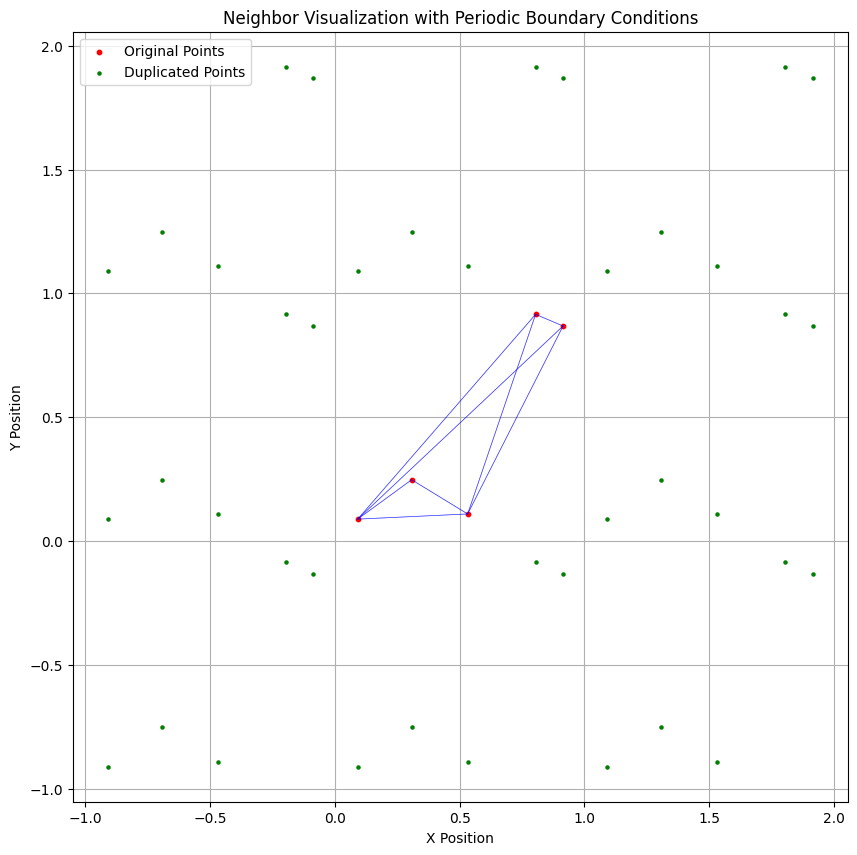

HUI


In [22]:
import h5py
import torch
from torch_geometric.nn import radius_graph
import matplotlib.pyplot as plt

# Load the dataset
with h5py.File(file_path, "r") as f:
    position = f["00000/position"][:]  # Load one trajectory
    frame = position[-1]  # Use the last time step of the sequence (shape: [2500, 2])

# Define domain size and periodic boundary shifts
# Convert to PyTorch tensor
frame_tensor = torch.tensor(
[[0.0917, 0.0882],
        [0.8043, 0.9152],
        [0.3077, 0.2472],
        [0.9143, 0.8680],
        [0.5321, 0.1090]], dtype=torch.float)



# Define domain size and periodic boundary shifts
domain_size = torch.tensor([1.0, 1.0])  # Assuming a unit square domain
shifts = torch.tensor([
    [dx, dy] for dx in [-1, 0, 1] for dy in [-1, 0, 1] if not (dx == 0 and dy == 0)
]).float() * domain_size  # Exclude the center (original frame)

# Duplicate the frame with periodic shifts
duplicated_frames = torch.cat([
    frame_tensor + shift for shift in shifts
], dim=0)  # Shape: [2500 * 8, 2]

# Combine original frame and duplicated frames for neighbor search
combined_positions = torch.cat([frame_tensor, duplicated_frames], dim=0)  # Shape: [2500 * 9, 2]

# Apply radius graph only for original particles
radius = 0.5
edge_index = radius_graph(combined_positions, r=radius)
# Filter edges to only keep those where the source is in the original frame
original_frame_size = frame_tensor.size(0)
is_from_original = edge_index[0] < original_frame_size #Mask all particles not from the original frame
filtered_edge_index = edge_index[:, is_from_original]
# filtered_edge_index = filtered_edge_index[1, :] % frame_tensor.size(0)
filtered_edge_index = filtered_edge_index % frame_tensor.size(0)
sorted_receiver, order = filtered_edge_index[1,:].sort()
filtered_edge_index[1,:] = sorted_receiver
filtered_edge_index[0,:] = filtered_edge_index[0,:][order]




# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(frame_tensor[:, 0], frame_tensor[:, 1], color='red', s=10, label="Original Points")
plt.scatter(duplicated_frames[:, 0], duplicated_frames[:, 1], color='green', s=5, label="Duplicated Points")

# Add lines for neighbors
for edge in filtered_edge_index.t():
    start, end = edge
    plt.plot(
        [combined_positions[start, 0], combined_positions[end, 0]],
        [combined_positions[start, 1], combined_positions[end, 1]],
        color="blue",
        alpha=0.5,
        linewidth=0.5
    )

plt.title("Neighbor Visualization with Periodic Boundary Conditions")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()

print("HUI")

/tmp/ipykernel_3315882/292014329.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  frame_tensor = torch.tensor(frame, dtype=torch.float)


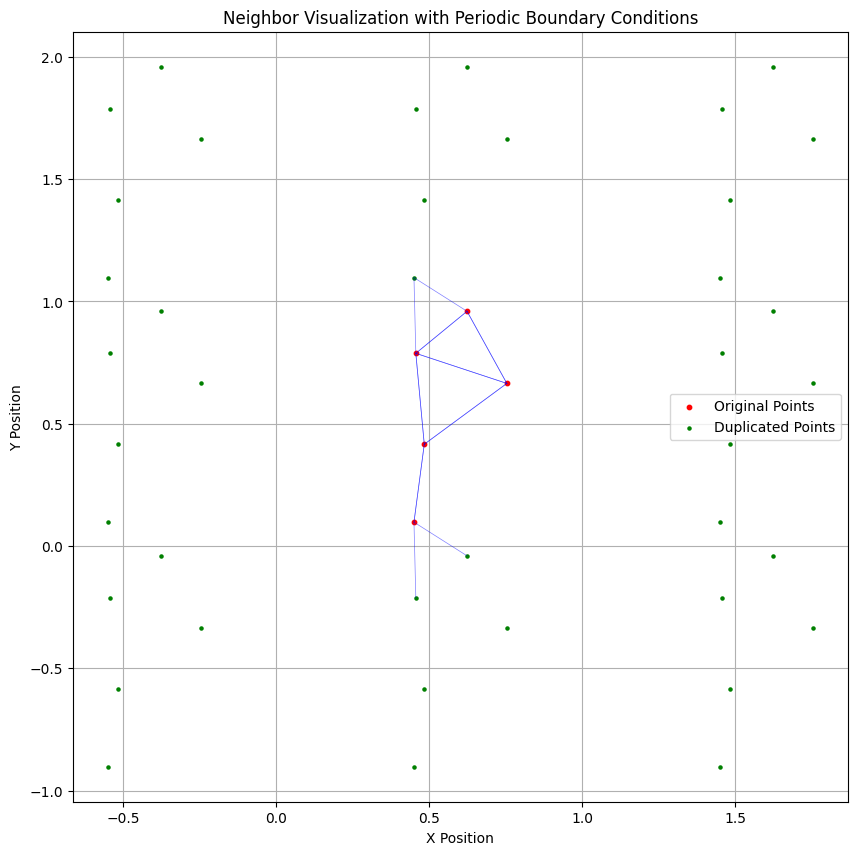

In [39]:
import h5py
import torch
from torch_geometric.nn import radius_graph
import matplotlib.pyplot as plt

# Load the dataset
with h5py.File(file_path, "r") as f:
    position = f["00000/position"][:]  # Load one trajectory
    frame = position[-1]  # Use the last time step of the sequence (shape: [2500, 2])

# Define domain size and periodic boundary shifts
frame = torch.rand(5, 2)
# Convert to PyTorch tensor
frame_tensor = torch.tensor(frame, dtype=torch.float)


# Define domain size and periodic boundary shifts
domain_size = torch.tensor([1.0, 1.0])  # Assuming a unit square domain
shifts = torch.tensor([
    [dx, dy] for dx in [-1, 0, 1] for dy in [-1, 0, 1] if not (dx == 0 and dy == 0)
]).float() * domain_size  # Exclude the center (original frame)

# Duplicate the frame with periodic shifts
duplicated_frames = torch.cat([
    frame_tensor + shift for shift in shifts
], dim=0)  # Shape: [2500 * 8, 2]

# Combine original frame and duplicated frames for neighbor search
combined_positions = torch.cat([frame_tensor, duplicated_frames], dim=0)  # Shape: [2500 * 9, 2]

# Apply radius graph only for original particles
radius = 0.4
edge_index = radius_graph(combined_positions, r=radius)

# Filter edges to only keep those where the source is in the original frame
original_frame_size = frame_tensor.size(0)
is_from_original = edge_index[0] < original_frame_size
filtered_edge_index = edge_index[:, is_from_original]

# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(frame_tensor[:, 0], frame_tensor[:, 1], color='red', s=10, label="Original Points")
plt.scatter(duplicated_frames[:, 0], duplicated_frames[:, 1], color='green', s=5, label="Duplicated Points")

# Add lines for neighbors
for edge in filtered_edge_index.t():
    start, end = edge
    plt.plot(
        [combined_positions[start, 0], combined_positions[end, 0]],
        [combined_positions[start, 1], combined_positions[end, 1]],
        color="blue",
        alpha=0.5,
        linewidth=0.5
    )

plt.title("Neighbor Visualization with Periodic Boundary Conditions")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_3318508/2011459836.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  frame_tensor = torch.tensor(frame, dtype=torch.float)


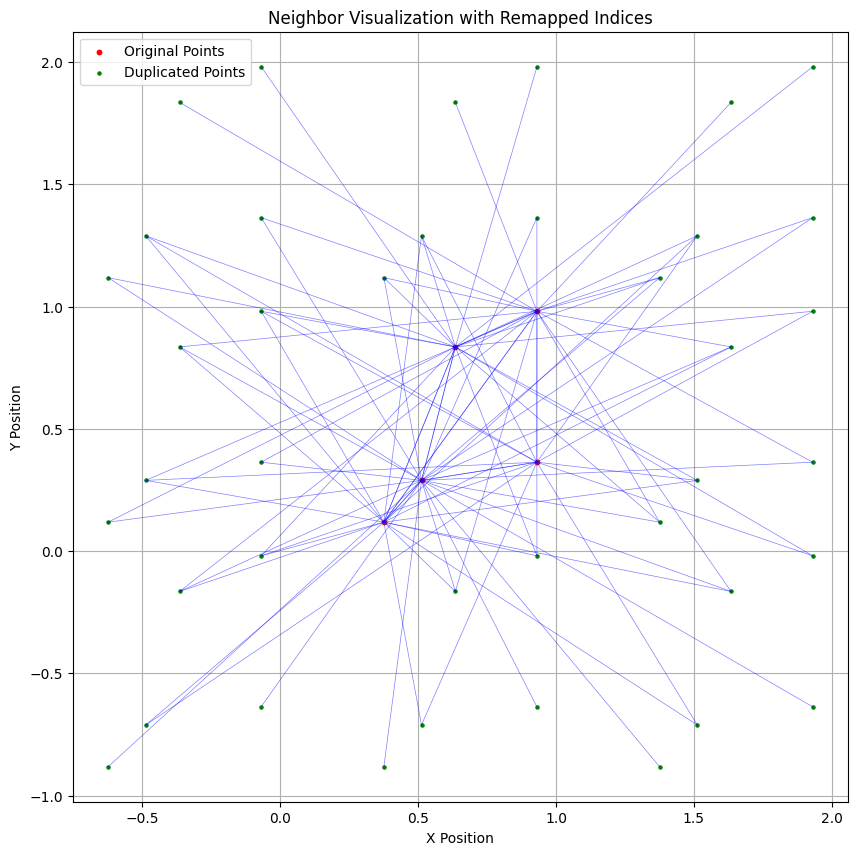

Original edge_index:
tensor([[ 3, 21,  4, 28, 25,  2, 29, 43,  1,  7, 21,  0, 22,  0,  9,  8,  7, 10,
         13,  3,  6, 14,  5,  5,  6, 14, 13, 12, 18, 15, 11, 28, 19,  6, 10,  7,
         10, 19, 18, 11, 17, 16, 11, 15, 15, 12, 23, 24,  3,  0, 22,  4, 38, 21,
         20, 20,  1, 28, 29, 27, 26, 12,  1, 25,  2, 25, 34, 33, 32, 35, 38, 31,
         39, 30, 30, 31, 38, 39, 37, 40, 43, 36, 44, 31, 35, 22, 32, 35, 36, 43,
         44, 42, 41, 36,  2, 40, 37, 40],
        [ 0,  0,  0,  1,  1,  1,  2,  2,  2,  3,  3,  3,  4,  4,  5,  5,  6,  6,
          6,  7,  7,  7,  8,  9, 10, 10, 10, 11, 11, 11, 12, 12, 12, 13, 13, 14,
         14, 15, 15, 15, 16, 17, 18, 18, 19, 19, 20, 20, 21, 21, 21, 22, 22, 22,
         23, 24, 25, 25, 25, 26, 27, 28, 28, 28, 29, 29, 30, 30, 31, 31, 31, 32,
         32, 33, 34, 35, 35, 35, 36, 36, 36, 37, 37, 38, 38, 38, 39, 39, 40, 40,
         40, 41, 42, 43, 43, 43, 44, 44]])

Mapped edge_index:
tensor([[ 3, 21,  4, 28, 25,  2, 29, 43,  1,  7, 21,  0, 22,  0,

In [11]:
import torch
from torch_geometric.nn import radius_graph
import matplotlib.pyplot as plt

# Original frame (5 particles in a 2D unit square)
frame = torch.rand(5, 2)

# Convert to PyTorch tensor
frame_tensor = torch.tensor(frame, dtype=torch.float)

# Define domain size and periodic boundary shifts
domain_size = torch.tensor([1.0, 1.0])  # Assuming a unit square domain
shifts = torch.tensor([
    [dx, dy] for dx in [-1, 0, 1] for dy in [-1, 0, 1] if not (dx == 0 and dy == 0)
]).float() * domain_size  # Exclude the center (original frame)

# Duplicate the frame with periodic shifts
duplicated_frames = torch.cat([
    frame_tensor + shift for shift in shifts
], dim=0)  # Shape: [10 * 8, 2]

# Combine original frame and duplicated frames for neighbor search
combined_positions = torch.cat([frame_tensor, duplicated_frames], dim=0)  # Shape: [10 * 9, 2]

# Apply radius graph
radius = 0.5
edge_index = radius_graph(combined_positions, r=radius)

# Map indices of particles outside the original frame back to [0-9]
# Original frame size
original_frame_size = frame_tensor.size(0)

# Function to map indices > 9 back to the range [0-9]
def map_to_original(idx, original_frame_size):
    # Calculate the shift that was applied to the duplicated particles
    duplicate_offset = (idx - original_frame_size) // original_frame_size
    return idx % original_frame_size

# Remap edge indices
mapped_edge_index = edge_index.clone()
mapped_edge_index[1] = torch.where(
    edge_index[1] >= original_frame_size,
    map_to_original(edge_index[1], original_frame_size),
    edge_index[1]
)

# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(frame_tensor[:, 0], frame_tensor[:, 1], color='red', s=10, label="Original Points")
plt.scatter(duplicated_frames[:, 0], duplicated_frames[:, 1], color='green', s=5, label="Duplicated Points")

# Add lines for neighbors
for edge in mapped_edge_index.t():
    start, end = edge
    plt.plot(
        [combined_positions[start, 0], combined_positions[end, 0]],
        [combined_positions[start, 1], combined_positions[end, 1]],
        color="blue",
        alpha=0.5,
        linewidth=0.5
    )

plt.title("Neighbor Visualization with Remapped Indices")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()

# Debugging output
print("Original edge_index:")
print(edge_index)
print("\nMapped edge_index:")
print(mapped_edge_index)
